In [1]:
import numpy as np
import matplotlib.pyplot as plt


from sklearn import datasets
digits = datasets.load_digits()
X, y = digits.data, digits.target
print(digits.images.shape)
print(digits.keys())

(1797, 8, 8)
dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])


# Tasks

## Part 1. Unsupervised Learning: Dimensionality Reduction on Digits

We'd like to visualize our points within the 64-dimensional parameter space, but it's difficult to plot points in $N=64$ dimensions! So we need to reduce the dimensionality of the space

Use the unsupervised dimensionality reduction technique called Isomap. Isomap is an embedding tecnique, which tries to understand if your $N$ dimensional datapoint live in a $M$ dimensional (with $M<N$) manyfold. Reduce the MINST dataset. Do some plots to visualize your results

In [2]:
print(digits.DESCR)

.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each block. This generates
an in

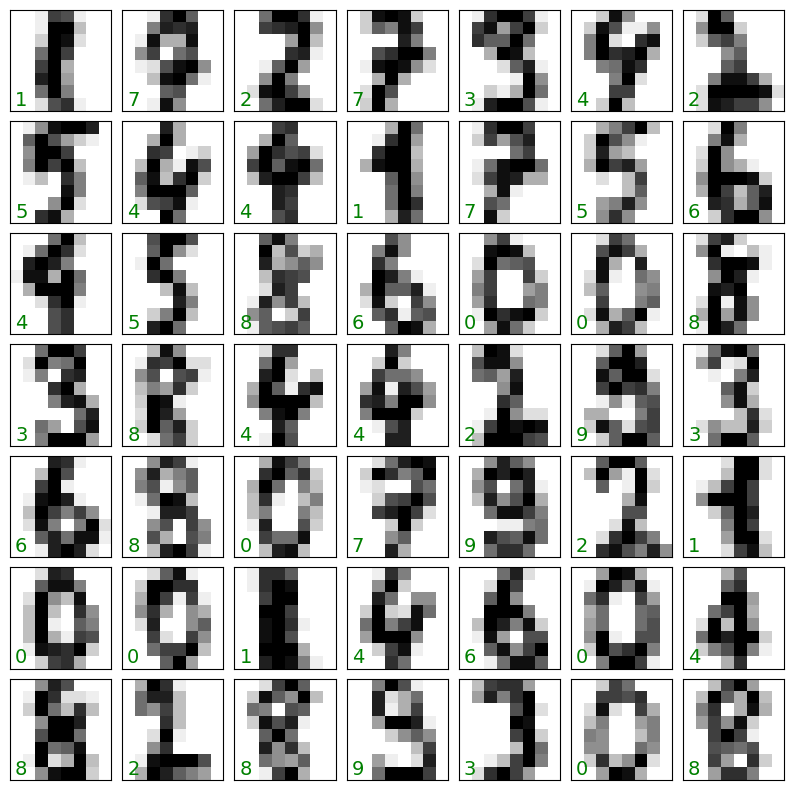

In [3]:
fig, axes = plt.subplots(7,7, figsize=(10, 10))
fig.subplots_adjust(hspace=0.1, wspace=0.1)

np.random.seed(42)
mychoices = np.random.choice(digits.images.shape[0],100)

for i, ax in enumerate(axes.flat):
    ax.imshow((digits.images[mychoices[i]]), 
              cmap='binary')
    ax.text(0.05, 0.05, str(digits.target[mychoices[i]]),transform=ax.transAxes, color='green', fontsize=14)
    ax.set_xticks([])
    ax.set_yticks([])

In [4]:
print(digits.data.shape)

# The images themselves
print(digits.images[0])

# The data for use in our algorithms
print(digits.data[0])

# The labels
print(digits.target)
print(digits.target[0])

(1797, 64)
[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]
[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]
[0 1 2 ... 8 9 8]
0


In [5]:
from sklearn.manifold import Isomap 

embedding = Isomap(n_components=2)
data_transformed = embedding.fit_transform(digits.data)
print(digits.data.shape, "-->", data_transformed.shape)

c:\Users\annat\anaconda3\envs\astro_env\Lib\site-packages\sklearn\manifold\_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
c:\Users\annat\anaconda3\envs\astro_env\Lib\site-packages\scipy\sparse\_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


(1797, 64) --> (1797, 2)


In [20]:
from sklearn.preprocessing import MinMaxScaler
from matplotlib import offsetbox

def plot_embedding(X, title):
    _, ax = plt.subplots(figsize=(10, 10))
    X =  Isomap(n_components=2).fit_transform(X)#MinMaxScaler().fit_transform(X)

    for digit in digits.target_names:
        ax.scatter(
            *X[y == digit].T,
            marker=f"${digit}$",
            s=60,
            color=plt.cm.Dark2(digit),
            alpha=0.425,
            zorder=2,
        )
    shown_images = np.array([[1.0, 1.0]])  # just something big
    for i in range(X.shape[0]):
        # plot every digit on the embedding
        # show an annotation box for a group of digits
        dist = np.sum((X[i] - shown_images) ** 2, 1)
        if np.min(dist) < 1000:#4e-1:
            # don't show points that are too close
            continue
        shown_images = np.concatenate([shown_images, [X[i]]], axis=0)
        imagebox = offsetbox.AnnotationBbox(
            offsetbox.OffsetImage(digits.images[i], cmap=plt.cm.gray_r), X[i]
        )
        imagebox.set(zorder=1)
        ax.add_artist(imagebox)

    ax.set_title(title)
    ax.axis("off")

c:\Users\annat\anaconda3\envs\astro_env\Lib\site-packages\sklearn\manifold\_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
c:\Users\annat\anaconda3\envs\astro_env\Lib\site-packages\scipy\sparse\_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


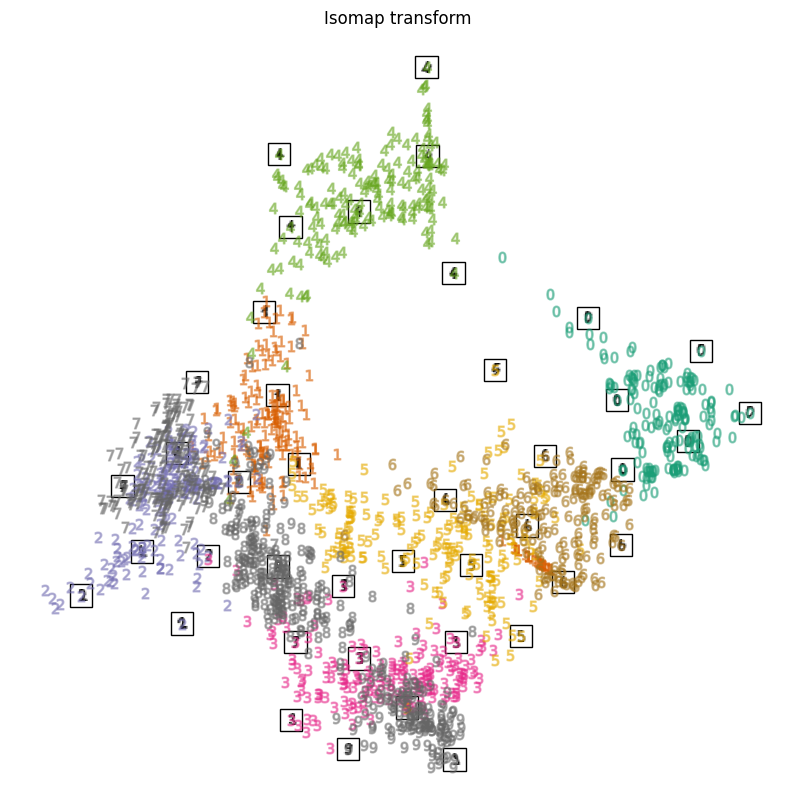

In [21]:

plot_embedding(digits.data, 'Isomap transform')
#data_transformed, 'Isomap transform')


C:\Users\annat\AppData\Local\Temp\ipykernel_14000\1294744550.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  alpha=0.6, cmap=plt.cm.get_cmap('jet', 10))


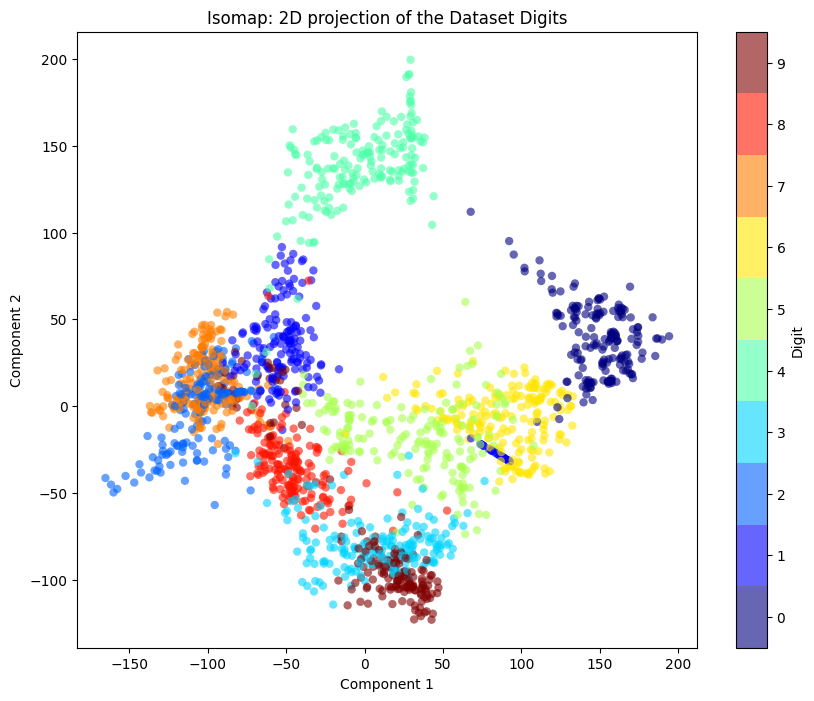

In [22]:
plt.figure(figsize=(10, 8))
plt.scatter(data_transformed[:, 0], data_transformed[:, 1], c=y, edgecolor='none', 
            alpha=0.6, cmap=plt.cm.get_cmap('jet', 10))

plt.colorbar(label='Digit', ticks=range(10))
plt.clim(-0.5, 9.5)
plt.title('Isomap: 2D projection of the Dataset Digits')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.show()

The 2D projection clearly shows clustering of similar digits, ex. 1, 2 and 7. 

## Part 2. Supervised Learning: Classification on Digits

Now we want to classify the dataset.

* Split the dataset taking 80% of the images as tranining dataset and leaving the other 20% as a validation set. You need sklearn.model_selection.train_test_split.

* Use a simple Logistic Regression which despite its name is a common classification algorithm. (I know, this is confusing!). Use the flag solver='sag' (I found the default solver had a bug, at least when I tried).

* Compute the accuracy (sklearn.metrics.accuracy_score) of your emulator. In this context, accuracy is simply the fraction of the digits that were correctly identified. Compute the accuracy on both the training and the validation set. Comment on the results.

* The accuracy is a single number doesn't tell us where we've gone wrong. Plot the confusion matrix as we did above. What are the digits that are more challenging to identify, does it make sense?

There are many ways to improve this classifier, for example using a more sophisticated model, use cross validation, etc. We'll get to those in the coming weeks.

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Dataset splitting (80% training, 20% validation)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)#, random_state=21)
print(X_train.shape, X_test.shape)

# Initialization and training
# Use of solver='sag' (Stochastic Average Gradient)
model = LogisticRegression(solver='sag', max_iter=2000) #max_iter can be increased
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Accuracy
acc_train = accuracy_score(y_train, y_train_pred)
acc_test = accuracy_score(y_test, y_test_pred)

print(f"Accuracy on Training set: {acc_train:.4f}")
print(f"Accuracy on Validation set: {acc_test:.4f}")

(1437, 64) (360, 64)
Accuracy on Training set: 1.0000
Accuracy on Validation set: 0.9694


<Figure size 1000x1000 with 0 Axes>

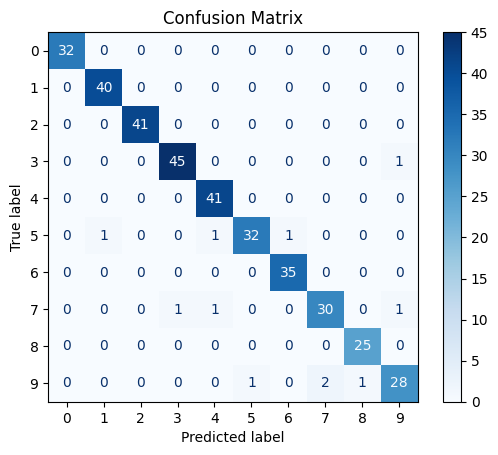

In [24]:
plt.figure(figsize=(10, 10))
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=digits.target_names)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Confusion Matrix')
plt.show()

The model achieved high accuracy (>95%) on both sets, indicating good generalization and no significant overfitting.

The confusion matrix revealed that the most challenging digits were 1, 8, and 9.

These digits indeed share very similar pixel patterns (e.g., the vertical stroke of a 1 vs. the compressed loops of an 8).
Therefore, the errors are "physically" reasonable as they correspond to visual similarities that are hard to distinguish even for humans at such low resolutions.

5-fold cross-validation accuracies: [0.9826 0.9479 0.9373 0.9512 0.9756]
Mean CV accuracy: 0.9589 ± 0.0173
Validation set accuracy: 0.9694
Cross-validated accuracy on full dataset: 0.9132


<Figure size 1000x1000 with 0 Axes>

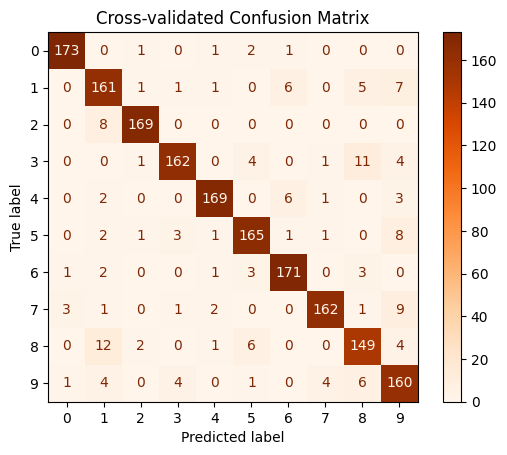

In [25]:
from sklearn.model_selection import cross_val_score, cross_val_predict

cv_model = LogisticRegression(solver='sag', max_iter=2000)

cv_scores = cross_val_score(
    cv_model,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
)

print("5-fold cross-validation accuracies:", np.round(cv_scores, 4))
print(f"Mean CV accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Validation set accuracy: {acc_test:.4f}")

y_cv_pred = cross_val_predict(cv_model, X, y, cv=5, n_jobs=-1)
cv_acc = accuracy_score(y, y_cv_pred)
print(f"Cross-validated accuracy on full dataset: {cv_acc:.4f}")

cm_cv = confusion_matrix(y, y_cv_pred)
disp_cv = ConfusionMatrixDisplay(confusion_matrix=cm_cv, display_labels=digits.target_names)
plt.figure(figsize=(10, 10))
disp_cv.plot(cmap=plt.cm.Oranges, values_format='d')
plt.title("Cross-validated Confusion Matrix")
plt.show()

train_size=0.5: train_acc=1.0000±0.0000, test_acc=0.9600±0.0058
train_size=0.6: train_acc=1.0000±0.0000, test_acc=0.9616±0.0040
train_size=0.7: train_acc=1.0000±0.0000, test_acc=0.9615±0.0036
train_size=0.8: train_acc=1.0000±0.0000, test_acc=0.9633±0.0067
train_size=0.9: train_acc=1.0000±0.0000, test_acc=0.9644±0.0130


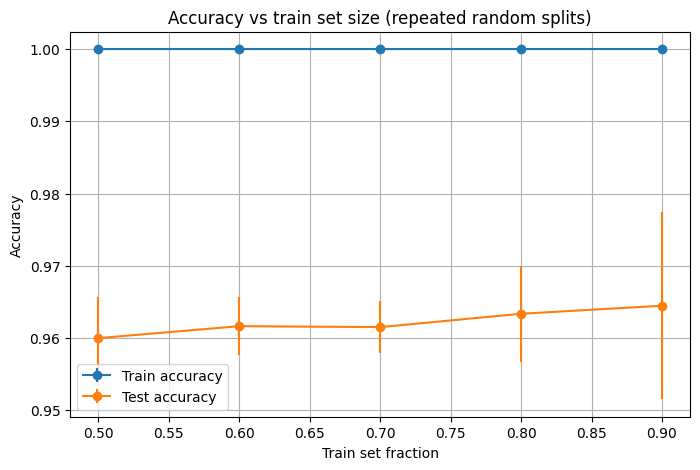

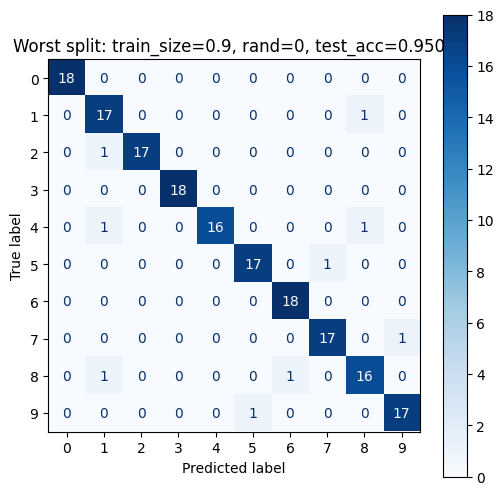

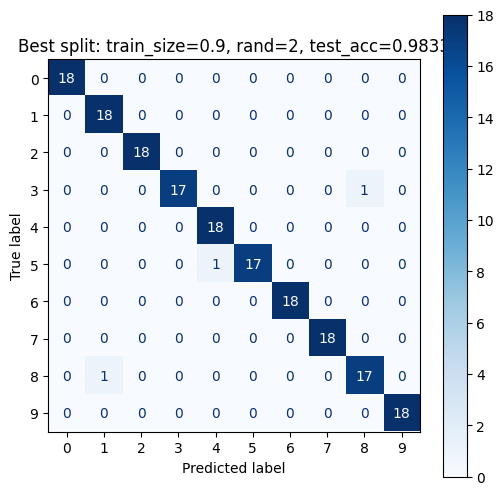

In [ ]:
# Cross-validate over different train sizes and random splits
train_sizes = [0.5, 0.6, 0.7, 0.8, 0.9]
n_repeats = 5
random_states = np.arange(n_repeats)

results = {ts: {"train": [], "test": [], "records": []} for ts in train_sizes}

for ts in train_sizes:
    for rs in random_states:
        X_tr, X_te, y_tr, y_te = train_test_split(X, y, train_size=ts, random_state=int(rs), stratify=y)
        model = LogisticRegression(solver='sag', max_iter=2000)
        model.fit(X_tr, y_tr)
        y_tr_pred = model.predict(X_tr)
        y_te_pred = model.predict(X_te)
        tr_acc = accuracy_score(y_tr, y_tr_pred)
        te_acc = accuracy_score(y_te, y_te_pred)
        results[ts]["train"].append(tr_acc)
        results[ts]["test"].append(te_acc)
        # store record for possible inspection (train_size, random_state, y_true, y_pred)
        results[ts]["records"].append((int(rs), y_te.copy(), y_te_pred.copy()))

# Summarize
summary = []
for ts in train_sizes:
    tr_mean, tr_std = np.mean(results[ts]["train"]), np.std(results[ts]["train"])
    te_mean, te_std = np.mean(results[ts]["test"]), np.std(results[ts]["test"])
    summary.append((ts, tr_mean, tr_std, te_mean, te_std))
    print(f"train_size={ts:.1f}: train_acc={tr_mean:.4f}±{tr_std:.4f}, test_acc={te_mean:.4f}±{te_std:.4f}")

# Plot mean accuracy vs train size with error bars
plt.figure(figsize=(8,5))
train_means = [s[1] for s in summary]
train_stds  = [s[2] for s in summary]
test_means  = [s[3] for s in summary]
test_stds   = [s[4] for s in summary]
plt.errorbar(train_sizes, train_means, yerr=train_stds, label='Train accuracy', marker='o')
plt.errorbar(train_sizes, test_means,  yerr=test_stds,  label='Test accuracy',  marker='o')
plt.xlabel('Train set fraction')
plt.ylabel('Accuracy')
plt.title('Accuracy vs train set size (repeated random splits)')
plt.legend()
plt.grid(True)
plt.show()

# Show confusion matrices for best and worst observed test split across all sizes
all_records = []
for ts in train_sizes:
    for idx, te_acc in enumerate(results[ts]["test"]):
        rs, y_true, y_pred = results[ts]["records"][idx]
        all_records.append((te_acc, ts, rs, y_true, y_pred))

all_records.sort(key=lambda r: r[0])
worst = all_records[0]
best = all_records[-1]

for label, rec in [('Worst', worst), ('Best', best)]:
    acc, ts, rs, y_true, y_pred = rec
    cm_local = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,6))
    disp_local = ConfusionMatrixDisplay(confusion_matrix=cm_local, display_labels=digits.target_names)
    disp_local.plot(cmap=plt.cm.Blues, values_format='d', ax=plt.gca())
    plt.title(f'{label} split: train_size={ts:.1f}, rand={rs}, test_acc={acc:.4f}')
    plt.show()